<a href="https://colab.research.google.com/github/dant56/google-collab-notebook/blob/main/2_mnist_fashion_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [4]:
#normalize
x_train= x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0
#new channel
x_train= x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


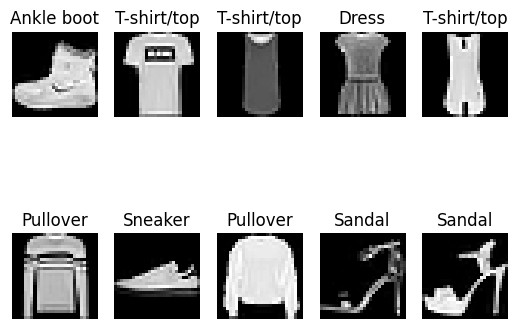

In [5]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress",
    "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap='grey')
  plt.title(class_names[y_train[i]])
  plt.axis('off')
plt.show()

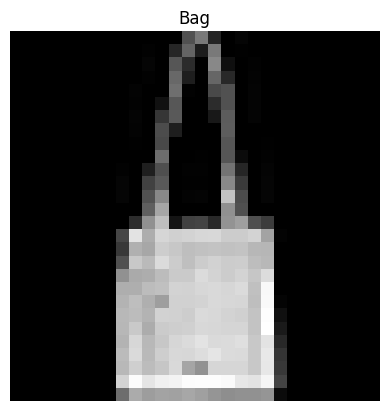

In [6]:
index =200
plt.imshow(x_train[index], cmap='grey')
plt.title(class_names[y_train[index]])
plt.axis('off')
plt.show()

In [7]:
model =models.Sequential([
    layers.Input( shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation= 'relu', padding='same',
                  kernel_initializer ='he_normal'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation= 'relu', padding='same',
                  kernel_initializer= 'he_normal'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation= 'relu', padding='same',
                  kernel_initializer = 'he_normal'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation= 'relu', padding='same',
                  kernel_initializer = 'he_normal'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu', kernel_initializer = 'he_normal'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,258 (692.41 KB)

 Trainable params: 176,810 (690.66 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train,y_train,
    batch_size=256,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.8104 - loss: 0.5395 - val_accuracy: 0.7732 - val_loss: 0.6207
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8799 - loss: 0.3309 - val_accuracy: 0.8873 - val_loss: 0.3017
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9004 - loss: 0.2728 - val_accuracy: 0.9077 - val_loss: 0.2498
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9114 - loss: 0.2407 - val_accuracy: 0.9127 - val_loss: 0.2460
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9233 - loss: 0.2111 - val_accuracy: 0.9162 - val_loss: 0.2292
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9301 - loss: 0.1872 - val_accuracy: 0.9175 - val_loss: 0.2280
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9368 - loss: 0.1702 - val_accuracy: 0.9207 - val_loss: 0.2279
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9436 - loss: 0.1526 - val_acc

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9177 - loss: 0.2676
Test accuracy: 0.9176999926567078


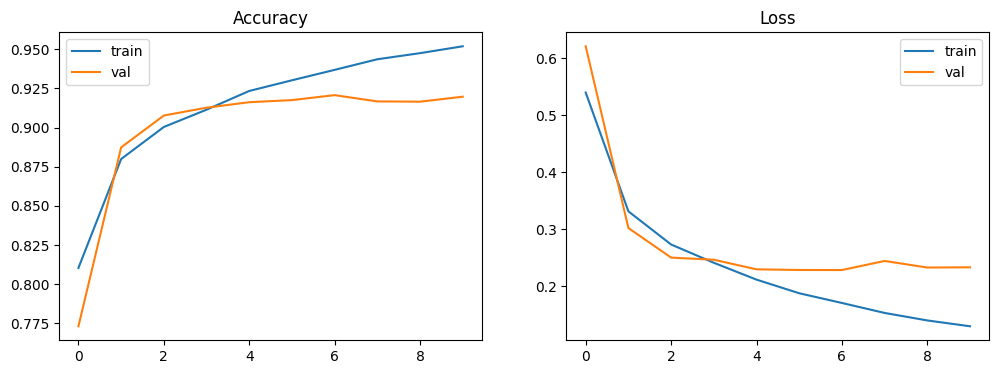

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


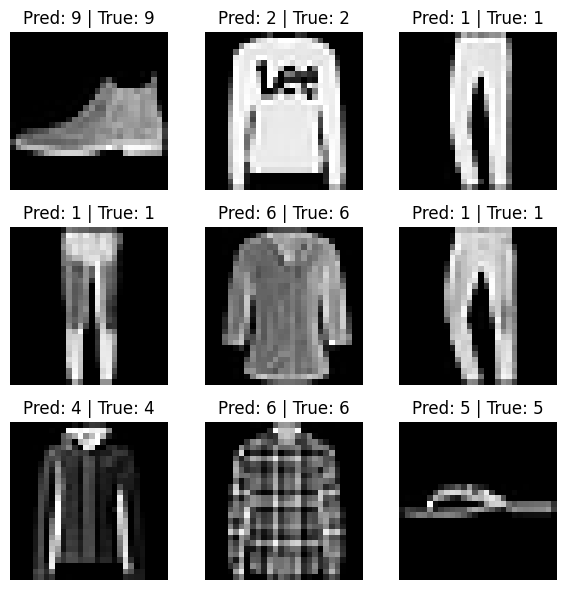

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.show()

preds = model.predict(x_test[:9])
fig, axes = plt.subplots(3,3, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].squeeze(), cmap='gray')
    ax.set_title(f"Pred: {np.argmax(preds[i])} | True: {y_test[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()